100%|██████████| 9.12M/9.12M [00:00<00:00, 79.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/imtkaggleteam/household-power-consumption/versions/1
Files found: ['household_power_consumption.csv']
Loading data from: /root/.cache/kagglehub/datasets/imtkaggleteam/household-power-consumption/versions/1/household_power_consumption.csv
Data loaded successfully! Shape: (1048575, 7)
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Missing values after ffill: 0
Daily data shape: (729, 1), Range: 2006-12-16 00:00:00 to 2008-12-13 00:00:00
Train size: 699, Test size: 30

Training ARIMA Model...
Training Prophet Model...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Training XGBoost Model...
--- ARIMA Performance ---
MAE: 0.2605
RMSE: 0.3695

--- Prophet Performance ---
MAE: 0.6136
RMSE: 0.6885

--- XGBoost Performance ---
MAE: 0.4053
RMSE: 0.4937



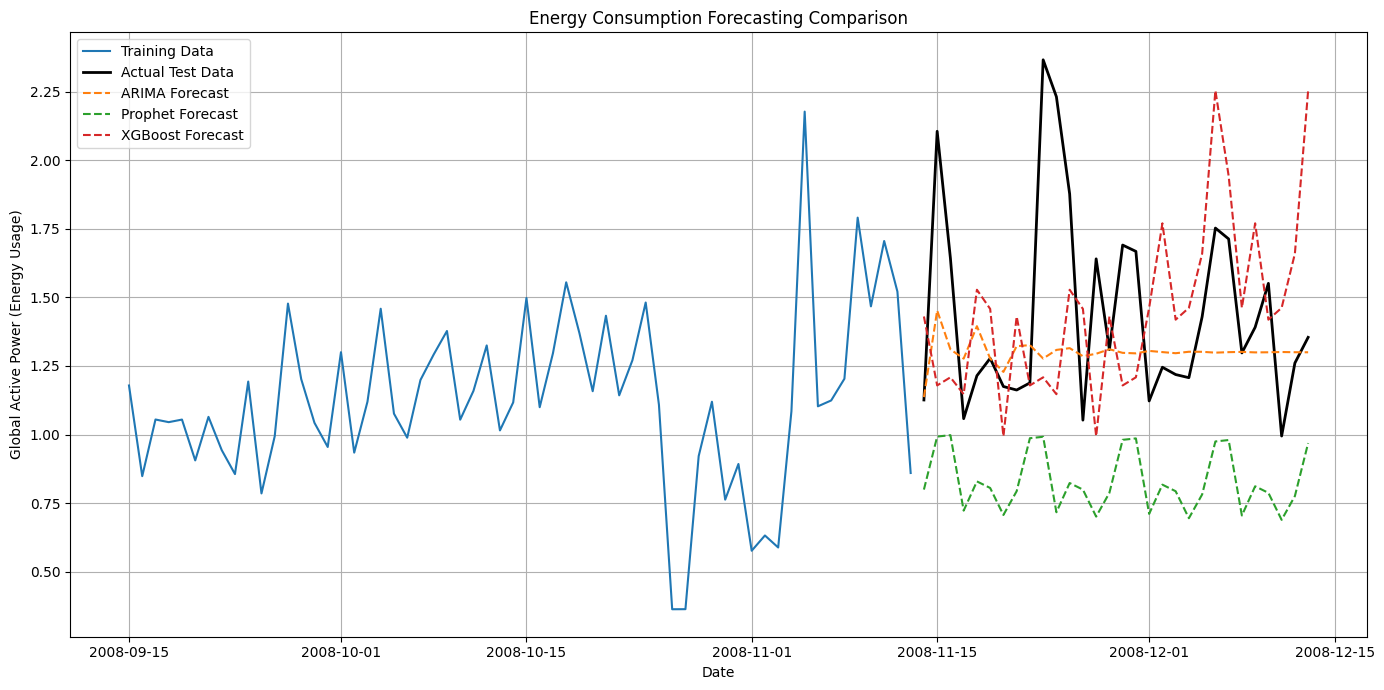

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# --- STEP 1: Parse and Resample the Time Series Data ---
# Dataset ko kagglehub se download karna
print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("imtkaggleteam/household-power-consumption")
print(f"Dataset downloaded to: {dataset_path}")

# Downloaded folder mein sahi file dhundna
files = os.listdir(dataset_path)
print(f"Files found: {files}")

# .txt ya .csv file automatically locate karna
data_file = None
for f in files:
    if f.endswith('.txt') or f.endswith('.csv'):
        data_file = os.path.join(dataset_path, f)
        break

if data_file is None:
    raise FileNotFoundError(f"No .txt or .csv file found in {dataset_path}. Files: {files}")

print(f"Loading data from: {data_file}")

# File extension ke hisaab se separator detect karna
sep = ';' if data_file.endswith('.txt') else ','

try:
    df = pd.read_csv(
        data_file,
        sep=sep,
        parse_dates={'datetime': ['Date', 'Time']},
        infer_datetime_format=True,
        low_memory=False,
        na_values=['?'],
        index_col='datetime'
    )
    print(f"Data loaded successfully! Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

except Exception as e:
    print(f"Standard parse failed ({e}), trying fallback load...")
    # Fallback: bina datetime parse kiye load karna
    df_raw = pd.read_csv(data_file, sep=sep, low_memory=False, na_values=['?'])
    print(f"Raw columns: {df_raw.columns.tolist()}")

    # Date + Time columns combine karke index set karna
    df_raw['datetime'] = pd.to_datetime(
        df_raw['Date'] + ' ' + df_raw['Time'],
        dayfirst=True,          # DD/MM/YYYY format handle karna
        errors='coerce'
    )
    df_raw.dropna(subset=['datetime'], inplace=True)
    df = df_raw.set_index('datetime').drop(columns=['Date', 'Time'], errors='ignore')
    print(f"Fallback load successful! Shape: {df.shape}")

# --- Column Name Normalize karna ---
# 'Global_active_power' ka naam consistent rakhna (spaces ya case differences handle karna)
col_map = {c: c.strip() for c in df.columns}
df.rename(columns=col_map, inplace=True)

if 'Global_active_power' not in df.columns:
    # Partial match try karna
    match = [c for c in df.columns if 'active' in c.lower() or 'power' in c.lower()]
    if match:
        df.rename(columns={match[0]: 'Global_active_power'}, inplace=True)
        print(f"Renamed '{match[0]}' -> 'Global_active_power'")
    else:
        raise KeyError(f"'Global_active_power' column nahi mila. Available: {df.columns.tolist()}")

# Missing values ko forward fill karna
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df.ffill(inplace=True)
print(f"Missing values after ffill: {df['Global_active_power'].isna().sum()}")

# Data ko Daily ('D') level par resample karna
daily_data = df['Global_active_power'].resample('D').mean().to_frame()
daily_data.columns = ['energy_usage']
daily_data.dropna(inplace=True)
print(f"Daily data shape: {daily_data.shape}, Range: {daily_data.index.min()} to {daily_data.index.max()}")

# --- STEP 2: Engineer Time-Based Features ---
daily_data['dayofweek'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['is_weekend'] = daily_data['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Train-Test Split (Last 30 days for testing)
test_size = 30
train = daily_data.iloc[:-test_size]
test = daily_data.iloc[-test_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

# --- STEP 3: Train Models & Compare Performance ---

# 1. ARIMA Model
print("\nTraining ARIMA Model...")
arima_model = ARIMA(train['energy_usage'], order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_preds = arima_fit.forecast(steps=test_size)

# 2. Prophet Model
print("Training Prophet Model...")
prophet_df = train.reset_index().rename(columns={'datetime': 'ds', 'energy_usage': 'y'})
# Index ka naam 'datetime' nahi hoga agar reset_index() use kiya — safely rename karna
if 'index' in prophet_df.columns:
    prophet_df.rename(columns={'index': 'ds'}, inplace=True)

prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=test_size)
prophet_forecast = prophet_model.predict(future)
prophet_preds = prophet_forecast.iloc[-test_size:]['yhat'].values

# 3. XGBoost Model
print("Training XGBoost Model...")
X_train = train[['dayofweek', 'month', 'is_weekend']]
y_train = train['energy_usage']
X_test = test[['dayofweek', 'month', 'is_weekend']]
y_test = test['energy_usage']

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# --- STEP 4: Evaluation (MAE, RMSE) ---
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {model_name} Performance ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}\n")

evaluate_model(test['energy_usage'], arima_preds, "ARIMA")
evaluate_model(test['energy_usage'], prophet_preds, "Prophet")
evaluate_model(test['energy_usage'], xgb_preds, "XGBoost")

# --- STEP 5: Plot Actual vs. Forecasted Energy Usage ---
plt.figure(figsize=(14, 7))
plt.plot(train.index[-60:], train['energy_usage'].iloc[-60:], label='Training Data')
plt.plot(test.index, test['energy_usage'], label='Actual Test Data', color='black', linewidth=2)
plt.plot(test.index, arima_preds, label='ARIMA Forecast', linestyle='dashed')
plt.plot(test.index, prophet_preds, label='Prophet Forecast', linestyle='dashed')
plt.plot(test.index, xgb_preds, label='XGBoost Forecast', linestyle='dashed')

plt.title('Energy Consumption Forecasting Comparison')
plt.xlabel('Date')
plt.ylabel('Global Active Power (Energy Usage)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()